# Optimizing customer support agents for cost and quality

This cookbook demonstrates a repeatable optimization sprint for a tool-using agent: measure a baseline, change one part of the workflow, and check quality before accepting savings. It uses synthetic e-commerce support tickets and a deterministic simulation that runs without API spend. The same measurement loop applies to other agent workflows.

By the end, you will have a repeatable pattern for:

- Measuring quality, latency, tool use, and total cost on the same evaluation set.
- Reducing unnecessary work through prompt and tool controls, model routing, and prompt caching.
- Separating customer-facing work from offline follow-up and checking the resulting tradeoffs.

The code defaults to dry-run mode. The optional live helpers require `OPENAI_API_KEY` and `RUN_LIVE_API_CALLS=true`.


## Outline

1. Define success criteria and a small representative eval set.
2. Build the intentionally inefficient baseline support agent.
3. Measure baseline cost, tokens, quality, latency, and tool calls.
4. Apply prompt, output, tool, and context controls.
5. Route simple steps to smaller models.
6. Restructure requests for prompt caching.
7. Split real-time and follow-up work.
8. Add monitoring, evals, and guardrails.

## Use case and agent setup

Our fictional e-commerce assistant handles order status, damaged deliveries, refund eligibility, duplicate charges, and account access. Routine lookups make smaller models worth evaluating; policy-sensitive cases test whether the optimized workflow still escalates correctly.

The five mock tools represent an order system (`lookup_order`), customer records (`lookup_customer`), a policy source (`lookup_policy`), refund or replacement cases (`create_refund_case`), and human support (`escalate_to_human`). These are local Python functions, so even the live model examples cannot change a real customer account.

The baseline exposes every tool, returns oversized payloads, and uses a full model for every step. It also performs internal QA, analytics tagging, and routing audits before replying. Later rounds keep the business task constant while reducing unnecessary work and moving follow-up processing out of the customer-facing path.


## References

**Last verified: September 14, 2026.** The examples use GPT-5.4 models; the model-selection and caching sections also describe considerations for GPT-5.6.

| Reference | Details used here |
|---|---|
| [Responses API](https://developers.openai.com/api/reference/resources/responses/methods/create) | Output limits, reasoning, verbosity, usage, conversation state, and service tiers |
| [Function calling](https://developers.openai.com/api/docs/guides/function-calling) | Function schemas, `allowed_tools`, and forwarding reasoning and tool-call items |
| [Prompt caching](https://developers.openai.com/api/docs/guides/prompt-caching) | Stable prefixes, model-specific caching controls, and token accounting |
| [Compaction](https://developers.openai.com/api/docs/guides/compaction) | `context_management` and `compact_threshold` |
| [Cost optimization](https://developers.openai.com/api/docs/guides/cost-optimization) | Fewer requests, smaller token budgets, and model selection |
| [Batch API](https://developers.openai.com/api/docs/guides/batch) and [flex processing](https://developers.openai.com/api/docs/guides/flex-processing) | Offline processing, the Batch `24h` window, and flex availability tradeoffs |
| [GPT-5.4](https://developers.openai.com/api/docs/models/gpt-5.4), [mini](https://developers.openai.com/api/docs/models/gpt-5.4-mini), and [nano](https://developers.openai.com/api/docs/models/gpt-5.4-nano) | Standard text-token prices and supported reasoning settings |


## Setup

Use Python 3.10 or later. Clone the Cookbook repository or download this entire [example folder](https://github.com/openai/openai-cookbook/tree/main/examples/agent_optimization), then start the notebook with `examples/agent_optimization` as the working directory so its local imports resolve.

Install the dependencies in your notebook's environment:

```bash
pip install --upgrade openai pandas matplotlib jinja2 ipykernel
```

The same dependencies are listed in [requirements.txt](https://github.com/openai/openai-cookbook/blob/bb95430abb908c1edddc38af5911109ab2ce3987/examples/agent_optimization/requirements.txt). `jinja2` is required for the styled pandas tables. The supporting files contain [mock data, tools, and prompts](https://github.com/openai/openai-cookbook/blob/bb95430abb908c1edddc38af5911109ab2ce3987/examples/agent_optimization/support.py), [simulation and checks](https://github.com/openai/openai-cookbook/blob/bb95430abb908c1edddc38af5911109ab2ce3987/examples/agent_optimization/simulation.py), [live API helpers](https://github.com/openai/openai-cookbook/blob/bb95430abb908c1edddc38af5911109ab2ce3987/examples/agent_optimization/live_api.py), [offline answer evaluation](https://github.com/openai/openai-cookbook/blob/bb95430abb908c1edddc38af5911109ab2ce3987/examples/agent_optimization/evaluation.py), and [scenario scoring](https://github.com/openai/openai-cookbook/blob/bb95430abb908c1edddc38af5911109ab2ce3987/examples/agent_optimization/scenarios.py).

The notebook does not call the API by default. To opt in to the live agent example, set these variables before starting the kernel:

```bash
export OPENAI_API_KEY=...
export RUN_LIVE_API_CALLS=true
```

The optional answer judge has its own switch, `RUN_LLM_JUDGE=true`, and also requires `OPENAI_API_KEY`. It grades the 50 existing simulated traces (10 tickets × 5 variants) with 50 paid judge requests; it does not run the live agent. Leave both switches unset for a fully offline run.

Run the cells from top to bottom. The Batch example writes a local file under `outputs/`; its submission code is displayed for inspection and is not executed.


In [ ]:
import json
import math
import os

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from openai import OpenAI

RUN_LIVE_API_CALLS = os.environ.get("RUN_LIVE_API_CALLS", "false").lower() == "true"
RUN_LLM_JUDGE = os.environ.get("RUN_LLM_JUDGE", "false").lower() == "true"
if (RUN_LIVE_API_CALLS or RUN_LLM_JUDGE) and not os.environ.get("OPENAI_API_KEY"):
    raise RuntimeError("Set OPENAI_API_KEY before enabling the live agent or judge.")
client = OpenAI() if RUN_LIVE_API_CALLS else None
judge_client = OpenAI() if RUN_LLM_JUDGE else None

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
print("RUN_LIVE_API_CALLS =", RUN_LIVE_API_CALLS)
print("RUN_LLM_JUDGE =", RUN_LLM_JUDGE)


RUN_LIVE_API_CALLS = True
RUN_LLM_JUDGE = True


## Success criteria and constraints

Accept savings only when the agent still uses the right facts, follows policy, takes the required action, and escalates correctly. A concise response must give the customer the next step without exposing internal data. Compare p50/p95 latency and total cost after those quality checks pass.

The eval set is deliberately small. In production, use a stratified sample covering your main intents, risk levels, languages, regions, customer tiers, and edge cases. Keep a holdout set and gate each optimization on quality before comparing savings.


## Simulation contract

The default path uses mock data and modeled metrics. It demonstrates the measurement loop; its numbers are not a production benchmark.

The harness measures serialized text lengths and compares tool, action, escalation, and response-phrase checks against the fixtures. Token counts are estimated from those lengths. Reasoning tokens, latency, cache hits, and the aggregate quality score follow illustrative formulas; cost applies the verified price table to estimated usage.

Routing and optimized actions come from the fixture labels, so this simulation does not measure a model's ability to choose them. Response checks use case-insensitive literal phrases, which can reject valid paraphrases and cannot establish factual correctness. For deployment decisions, replace these traces with real usage, timings, tool results, routing decisions, and calibrated judge or human evaluations.


## Optimization knobs

| Knob | Inefficient baseline | Optimized pattern | Primary metric |
|---|---|---|---|
| Prompt and output | Broad "be thorough" instructions and long answers | Specific task rules, concise response contract, `text.verbosity="low"`, capped output | Output tokens, concision, quality |
| Reasoning effort | High reasoning for every ticket | Low for routine work, higher only for high-risk decisions | Reasoning tokens, latency |
| Tool surface | All tools exposed for every request | Full stable tool list plus `tool_choice.allowed_tools` per task | Tool calls, cacheability |
| Tool schemas | Verbose descriptions and broad payload expectations | Small schemas with only decision-critical arguments | Input tokens |
| Tool payloads | Raw CRM, carrier, audit, and appendix blobs | Slim fields needed for the next decision | Tool output tokens |
| Model routing | One large model for all steps | Nano for triage/tags, mini for routine resolution, full model for high-risk cases | Cost, latency, escalation accuracy |
| Prompt caching | Volatile ticket data mixed into the prefix | Stable instructions, tools, policy framing, and schema first; ticket data last | Cached input tokens, cost |
| Workflow split | QA, analytics, summaries, and audits in the customer path | Customer resolution sync; QA/tags/reporting async via background, flex, or Batch | p50 latency, synchronous cost |
| Guardrails and evals | Informal spot checks | Deterministic checks plus judge schema for live traces | Regression rate, safety pass rate |


## Sample evaluation set

This small sample eval set gives the notebook concrete tickets, expected tools, expected actions, escalation labels, and forbidden claims to score each optimization round.


In [ ]:
from support import EVAL_SET

pd.DataFrame(EVAL_SET)[
    [
        "ticket_id",
        "intent",
        "risk",
        "difficulty",
        "expected_tools",
        "expected_action",
        "must_escalate",
    ]
]

,ticket_id,intent,risk,difficulty,expected_tools,expected_action,must_escalate
0,T-001,order_status,low,simple_lookup,[lookup_order],provide_status_eta,False
1,T-002,damaged_delivery,medium,routine_policy,"[lookup_order, lookup_policy]",request_photo_then_offer_replacement,False
2,T-003,refund_eligibility,medium,routine_policy,"[lookup_order, lookup_policy, create_refund_case]",open_refund_case,False
3,T-004,billing_issue,medium,sensitive_policy,"[lookup_order, lookup_policy, escalate_to_human]",escalate_billing_review,True
4,T-005,account_access,high,account_security,"[lookup_customer, lookup_policy, escalate_to_h...",escalate_account_security,True
5,T-006,refund_dispute,high,outside_policy_window,"[lookup_order, lookup_policy, escalate_to_human]",escalate_refund_review,True
6,T-007,delivered_not_received,medium,routine_policy,"[lookup_order, lookup_policy]",start_delivery_trace_steps,False
7,T-008,high_value_damage,high,high_value_policy,"[lookup_order, lookup_policy, escalate_to_human]",escalate_high_value_damage,True
8,T-009,refund_eligibility,low,routine_policy,"[lookup_order, lookup_policy, create_refund_case]",open_refund_case,False
9,T-010,account_access,high,account_security,"[lookup_customer, lookup_policy, escalate_to_h...",escalate_account_security,True


## Support data and tools

The five local tool functions in [support.py](https://github.com/openai/openai-cookbook/blob/bb95430abb908c1edddc38af5911109ab2ce3987/examples/agent_optimization/support.py) stand in for internal systems. The baseline returns oversized payloads to show how tool outputs can dominate input tokens; later rounds return only fields needed for the decision and response.

The following cell shows one slim order record. The mock action tools return synthetic results without creating real cases or escalations.


In [ ]:
from support import lookup_order

# Inspect the decision-critical fields returned by the slim payload.
print(json.dumps(lookup_order("O-1001", payload="slim"), indent=2))

{
  "found": true,
  "order_id": "O-1001",
  "status": "in_transit",
  "carrier": "UPS",
  "eta": "tomorrow",
  "delivered_days_ago": null,
  "payment_status": "paid_once",
  "item_value": 18.0,
  "events": [
    "regional_delay"
  ]
}


In [ ]:
from support import SLIM_TOOLS, VERBOSE_TOOLS, allowed_tool_choice

print("Verbose tool schema tokens:", math.ceil(len(json.dumps(VERBOSE_TOOLS)) / 4))
print("Slim tool schema tokens:", math.ceil(len(json.dumps(SLIM_TOOLS)) / 4))

Verbose tool schema tokens: 550
Slim tool schema tokens: 397


## Baseline architecture

The bad baseline does too much in one synchronous path.

```mermaid
flowchart LR
    A["Customer message"] --> B["One general agent on strongest model"]
    B --> C["Customer lookup"]
    B --> D["Order lookup"]
    B --> E["Policy lookup"]
    B --> F["Refund or escalation tools"]
    B --> G["Customer response"]
    B --> H["QA summary"]
    B --> I["Analytics tagging"]
    B --> J["Routing audit"]
```

Broad instructions, high reasoning effort, and unrestricted tools make each request expensive. Large schemas and verbose payloads inflate inputs, while long answers and synchronous QA add work before the customer receives a reply.


In [ ]:
from support import CONTROLLED_PROMPT

print(CONTROLLED_PROMPT)

Role: E-commerce support assistant.

Goal: Resolve routine support tickets with the fewest necessary tool calls while preserving policy correctness.

Tool rules:
- Use only tools required for the current decision.
- Order status: order lookup only.
- Damaged delivery or refund: order lookup plus the relevant policy.
- Billing duplicate charge: order lookup plus billing policy, then escalate.
- Account access with unverified identity: customer lookup plus account policy, then escalate.

Response rules:
- Give the customer the outcome and next step.
- Do not expose internal reasoning, raw tool data, audit notes, or policy text.
- Keep the customer-facing answer under 120 words unless escalation legally requires more detail.


## Metrics helpers

The live helper reads `input_tokens`, `output_tokens`, `total_tokens`, `input_tokens_details.cached_tokens`, and `output_tokens_details.reasoning_tokens`. Output-token usage already includes reasoning tokens; do not add them again when calculating cost.

The table below shows USD per million text tokens at standard rates, verified September 14, 2026 against the [GPT-5.4](https://developers.openai.com/api/docs/models/gpt-5.4), [mini](https://developers.openai.com/api/docs/models/gpt-5.4-mini), and [nano](https://developers.openai.com/api/docs/models/gpt-5.4-nano) pages. It covers the short GPT-5.4 requests used here. The estimator does not cover long-context premiums, priority pricing, or GPT-5.6 cache-write charges; update it before changing those settings. See the [pricing page](https://developers.openai.com/api/docs/pricing) for current rates.


In [ ]:
from simulation import MODEL_PRICES_USD_PER_1M

pd.DataFrame(MODEL_PRICES_USD_PER_1M).T.rename_axis("model")

,input,cached_input,output
model,,,
gpt-5.4,2.50,0.250,15.00
gpt-5.4-mini,0.75,0.075,4.50
gpt-5.4-nano,0.20,0.020,1.25


## Dry-run simulation

The [simulation helper](https://github.com/openai/openai-cookbook/blob/bb95430abb908c1edddc38af5911109ab2ce3987/examples/agent_optimization/simulation.py) applies each variant to the same tickets, estimates usage from prompts and payloads, and records the customer response with its quality checks. Missing required phrases and forbidden claims lower quality and fail the demo policy check, even when action and escalation labels match.

The optimized variants assume a correct application router and known expected actions. Caching uses a simplified warm-cache assumption and a 1,024-token eligibility threshold, not a measurement of actual cache behavior. The repeated playbook makes the demonstration large enough to exercise that branch; production prompts should contain useful shared context, and cache eligibility depends on request settings.

The final variant removes background work from synchronous latency while still counting its tokens and Batch cost. Inspect individual traces before relying on their averages.


In [ ]:
from simulation import CACHE_FRIENDLY_PROMPT, VARIANT_ORDER, simulate_trace

traces = pd.DataFrame(
    simulate_trace(ticket, variant)
    for variant in VARIANT_ORDER
    for ticket in EVAL_SET
)
traces.drop(columns="tool_results").head()

,variant,variant_label,ticket_id,intent,risk,difficulty,model,routing_tokens,tool_calls,expected_tools,tools,action,expected_action,input_tokens,latency_input_tokens,cacheable_prefix_tokens,cached_tokens,output_tokens,visible_output_tokens,reasoning_tokens,...,total_tokens,latency_s,sync_cost_usd,background_tokens,background_cost_usd,cost_usd,escalated,customer_response,missing_required_tools,extra_tool_calls,unnecessary_tools,escalation_correct,action_correct,policy_compliant,concise,response_complete,missing_required_phrases,forbidden_claims_absent,forbidden_claims_found,quality_score
0,00_bad_baseline,Bad baseline,T-001,order_status,low,simple_lookup,gpt-5.4,0,5,lookup_order,"lookup_customer, lookup_order, lookup_policy, ...",provide_status_eta,provide_status_eta,12301,12301,0,0,612,167,445,...,12913,4.88,0.039933,0,0.0,0.039933,False,I reviewed your message for ticket T-001 and c...,,4,"create_refund_case, escalate_to_human, lookup_...",True,True,False,False,False,"in transit, tomorrow",True,,0.55
1,00_bad_baseline,Bad baseline,T-002,damaged_delivery,medium,routine_policy,gpt-5.4,0,5,"lookup_order, lookup_policy","lookup_customer, lookup_order, lookup_policy, ...",open_replacement_without_photo,request_photo_then_offer_replacement,12273,12273,0,0,644,174,470,...,12917,4.88,0.040343,0,0.0,0.040343,False,I reviewed your message for ticket T-002 and c...,,3,"create_refund_case, escalate_to_human, lookup_...",True,False,False,False,True,,True,,0.65
2,00_bad_baseline,Bad baseline,T-003,refund_eligibility,medium,routine_policy,gpt-5.4,0,5,"lookup_order, lookup_policy, create_refund_case","lookup_customer, lookup_order, lookup_policy, ...",escalate_refund_review,open_refund_case,12178,12178,0,0,640,170,470,...,12818,4.87,0.040045,0,0.0,0.040045,True,I reviewed your message for ticket T-003 and c...,,2,"escalate_to_human, lookup_customer",False,False,False,False,False,"refund case, within 30 days",True,,0.22
3,00_bad_baseline,Bad baseline,T-004,billing_issue,medium,sensitive_policy,gpt-5.4,0,5,"lookup_order, lookup_policy, escalate_to_human","lookup_customer, lookup_order, lookup_policy, ...",escalate_billing_review,escalate_billing_review,12166,12166,0,0,664,169,495,...,12830,4.87,0.040375,0,0.0,0.040375,True,I reviewed your message for ticket T-004 and c...,,2,"create_refund_case, lookup_customer",True,True,True,False,True,,True,,0.85
4,00_bad_baseline,Bad baseline,T-005,account_access,high,account_security,gpt-5.4,0,5,"lookup_customer, lookup_policy, escalate_to_human","lookup_customer, lookup_order, lookup_policy, ...",escalate_account_security,escalate_account_security,7415,7415,0,0,697,172,525,...,8112,3.97,0.028993,0,0.0,0.028993,True,I reviewed your message for ticket T-005 and c...,,2,"create_refund_case, lookup_order",True,True,False,False,False,"account security, verification",True,,0.60


In [ ]:
summary = (
    traces.groupby(["variant", "variant_label"], sort=False)
    .agg(
        tickets=("ticket_id", "count"),
        mean_quality=("quality_score", "mean"),
        policy_compliance=("policy_compliant", "mean"),
        action_accuracy=("action_correct", "mean"),
        escalation_accuracy=("escalation_correct", "mean"),
        concise_rate=("concise", "mean"),
        mean_tool_calls=("tool_calls", "mean"),
        mean_extra_tool_calls=("extra_tool_calls", "mean"),
        mean_input_tokens=("input_tokens", "mean"),
        mean_cached_tokens=("cached_tokens", "mean"),
        mean_output_tokens=("output_tokens", "mean"),
        mean_reasoning_tokens=("reasoning_tokens", "mean"),
        mean_sync_tokens=("sync_tokens", "mean"),
        mean_total_tokens=("total_tokens", "mean"),
        p50_latency_s=("latency_s", "median"),
        p95_latency_s=("latency_s", lambda s: s.quantile(0.95)),
        sync_cost_per_ticket_usd=("sync_cost_usd", "mean"),
        background_cost_per_ticket_usd=("background_cost_usd", "mean"),
        cost_per_ticket_usd=("cost_usd", "mean"),
    )
    .reset_index()
)

baseline_cost = summary.loc[summary["variant"] == "00_bad_baseline", "cost_per_ticket_usd"].iloc[0]
baseline_tokens = summary.loc[summary["variant"] == "00_bad_baseline", "mean_total_tokens"].iloc[0]
baseline_latency = summary.loc[summary["variant"] == "00_bad_baseline", "p50_latency_s"].iloc[0]

summary["cost_reduction_vs_baseline"] = 1 - summary["cost_per_ticket_usd"] / baseline_cost
summary["token_reduction_vs_baseline"] = 1 - summary["mean_total_tokens"] / baseline_tokens
summary["latency_reduction_vs_baseline"] = 1 - summary["p50_latency_s"] / baseline_latency
summary["monthly_cost_at_100k_tickets"] = summary["cost_per_ticket_usd"] * 100_000

summary_view = summary[
    [
        "variant_label",
        "mean_quality",
        "policy_compliance",
        "action_accuracy",
        "escalation_accuracy",
        "mean_tool_calls",
        "mean_extra_tool_calls",
        "mean_sync_tokens",
        "mean_total_tokens",
        "mean_cached_tokens",
        "p50_latency_s",
        "cost_per_ticket_usd",
        "cost_reduction_vs_baseline",
        "monthly_cost_at_100k_tickets",
    ]
]

display(
    summary_view.style.format(
        {
            "mean_quality": "{:.2f}",
            "policy_compliance": "{:.0%}",
            "action_accuracy": "{:.0%}",
            "escalation_accuracy": "{:.0%}",
            "mean_tool_calls": "{:.1f}",
            "mean_extra_tool_calls": "{:.1f}",
            "mean_sync_tokens": "{:,.0f}",
            "mean_total_tokens": "{:,.0f}",
            "mean_cached_tokens": "{:,.0f}",
            "p50_latency_s": "{:.2f}",
            "cost_per_ticket_usd": "${:.5f}",
            "cost_reduction_vs_baseline": "{:.0%}",
            "monthly_cost_at_100k_tickets": "${:,.0f}",
        }
    )
)


,variant_label,mean_quality,policy_compliance,action_accuracy,escalation_accuracy,mean_tool_calls,mean_extra_tool_calls,mean_sync_tokens,mean_total_tokens,mean_cached_tokens,p50_latency_s,cost_per_ticket_usd,cost_reduction_vs_baseline,monthly_cost_at_100k_tickets
0,Bad baseline,0.51,10%,60%,70%,5.0,2.4,"11,935","11,935",0,4.88,$0.03813,0%,"$3,813"
1,Round 1: controls,0.98,100%,100%,100%,2.6,0.0,"1,379","1,379",0,2.32,$0.00512,87%,$512
2,Round 2: routing,0.98,100%,100%,100%,2.6,0.0,"1,485","1,485",0,1.87,$0.00302,92%,$302
3,Round 3: caching,0.98,100%,100%,100%,2.6,0.0,"2,684","2,684","1,779",1.85,$0.00244,94%,$244
4,Round 4: split workflow,0.98,100%,100%,100%,2.6,0.0,"2,412","2,974","1,779",1.41,$0.00204,95%,$204


## Round-by-round impact

Each row compares one round to the previous round. This makes the optimization knobs easier to reason about than a single before/after number.


In [ ]:
round_impact = summary[
    [
        "variant_label",
        "mean_quality",
        "policy_compliance",
        "mean_tool_calls",
        "mean_extra_tool_calls",
        "mean_sync_tokens",
        "mean_total_tokens",
        "mean_cached_tokens",
        "p50_latency_s",
        "cost_per_ticket_usd",
    ]
].copy()

for col in ["mean_sync_tokens", "mean_total_tokens", "p50_latency_s", "cost_per_ticket_usd"]:
    round_impact[f"{col}_delta_vs_previous"] = round_impact[col].diff()

round_impact["quality_delta_vs_previous"] = round_impact["mean_quality"].diff()

display(
    round_impact.style.format(
        {
            "mean_quality": "{:.2f}",
            "policy_compliance": "{:.0%}",
            "mean_tool_calls": "{:.1f}",
            "mean_extra_tool_calls": "{:.1f}",
            "mean_sync_tokens": "{:,.0f}",
            "mean_total_tokens": "{:,.0f}",
            "mean_cached_tokens": "{:,.0f}",
            "p50_latency_s": "{:.2f}",
            "cost_per_ticket_usd": "${:.5f}",
            "mean_sync_tokens_delta_vs_previous": "{:+,.0f}",
            "mean_total_tokens_delta_vs_previous": "{:+,.0f}",
            "p50_latency_s_delta_vs_previous": "{:+.2f}",
            "cost_per_ticket_usd_delta_vs_previous": "${:+.5f}",
            "quality_delta_vs_previous": "{:+.2f}",
        }
    )
)


,variant_label,mean_quality,policy_compliance,mean_tool_calls,mean_extra_tool_calls,mean_sync_tokens,mean_total_tokens,mean_cached_tokens,p50_latency_s,cost_per_ticket_usd,mean_sync_tokens_delta_vs_previous,mean_total_tokens_delta_vs_previous,p50_latency_s_delta_vs_previous,cost_per_ticket_usd_delta_vs_previous,quality_delta_vs_previous
0,Bad baseline,0.51,10%,5.0,2.4,"11,935","11,935",0,4.88,$0.03813,+nan,+nan,+nan,$+nan,+nan
1,Round 1: controls,0.98,100%,2.6,0.0,"1,379","1,379",0,2.32,$0.00512,"-10,556","-10,556",-2.56,$-0.03301,+0.48
2,Round 2: routing,0.98,100%,2.6,0.0,"1,485","1,485",0,1.87,$0.00302,+106,+106,-0.45,$-0.00210,+0.00
3,Round 3: caching,0.98,100%,2.6,0.0,"2,684","2,684","1,779",1.85,$0.00244,"+1,199","+1,199",-0.02,$-0.00058,+0.00
4,Round 4: split workflow,0.98,100%,2.6,0.0,"2,412","2,974","1,779",1.41,$0.00204,-272,+290,-0.44,$-0.00040,+0.00


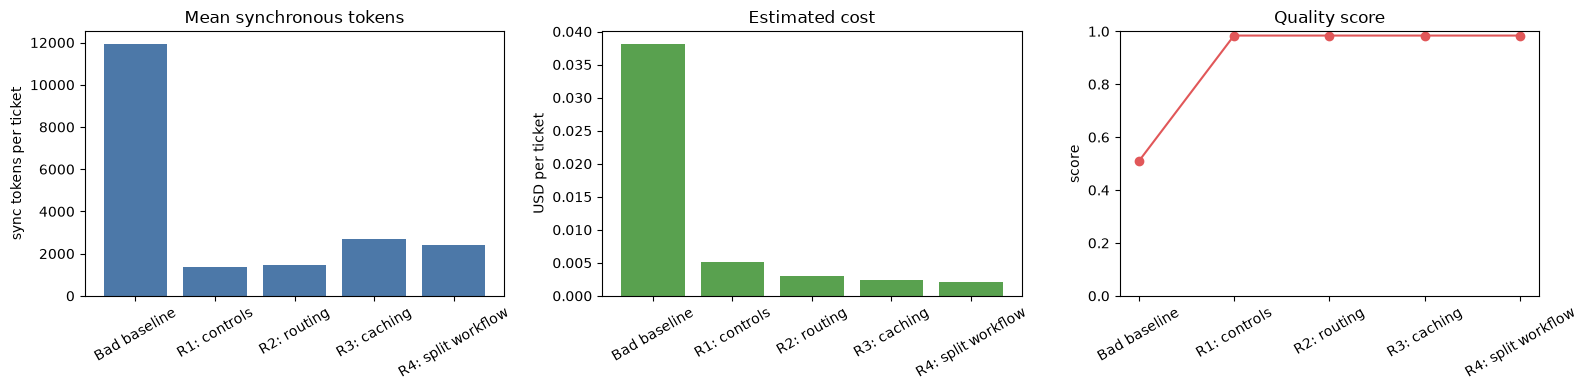

In [ ]:
plot_df = summary.copy()
labels = plot_df["variant_label"].str.replace("Round ", "R", regex=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].bar(labels, plot_df["mean_sync_tokens"], color="#4C78A8")
axes[0].set_title("Mean synchronous tokens")
axes[0].set_ylabel("sync tokens per ticket")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(labels, plot_df["cost_per_ticket_usd"], color="#59A14F")
axes[1].set_title("Estimated cost")
axes[1].set_ylabel("USD per ticket")
axes[1].tick_params(axis="x", rotation=30)

axes[2].plot(labels, plot_df["mean_quality"], marker="o", color="#E15759")
axes[2].set_ylim(0, 1.0)
axes[2].set_title("Quality score")
axes[2].set_ylabel("score")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## Optional: live Responses API tool loop

The implementation in [live_api.py](https://github.com/openai/openai-cookbook/blob/bb95430abb908c1edddc38af5911109ab2ce3987/examples/agent_optimization/live_api.py) forwards `response.output` before appending function results, preserving reasoning and tool-call items. Follow-up requests retain the configured tool choice, allowing an order and policy lookup followed by a refund call. After `max_tool_rounds` batches, the final request uses `tool_choice="none"` to obtain an answer without executing more tools.

The example uses a refund ticket and derives its allowed tools from that same ticket. This router still uses fixture labels; replace it with evaluated application logic for live traffic. An incomplete response or an unexpected final tool call raises an error instead of being reported as a completed answer.

For separate conversational turns, `previous_response_id` can carry state. Supply instructions again when they should apply to the next request.


In [ ]:
from live_api import (
    background_followup_request,
    live_config_for_ticket,
    run_live_support_ticket,
)

# Keep the allowed tools tied to the ticket being evaluated.
live_ticket = EVAL_SET[2]  # Order/policy lookup, then open a refund case.
live_config = live_config_for_ticket(live_ticket, "01_prompt_tool_context_controls")

In [ ]:
if RUN_LIVE_API_CALLS:
    live_result = run_live_support_ticket(live_ticket, live_config, client=client)
    print(live_result["response_text"])
    display(pd.DataFrame([{k: v for k, v in live_result.items() if k not in {"response_text", "tool_results"}}]))
else:
    print("Dry-run mode. Set OPENAI_API_KEY and RUN_LIVE_API_CALLS=true to run a live Responses API ticket.")


Your refund request is eligible, and I’ve opened a return/refund case for order O-1003.

Next step: please use the return instructions from your order page or confirmation email to send the item back. Once the return is received and processed, your refund will be issued.


,config,ticket_id,model,tool_calls,latency_s,estimated_cost_usd,input_tokens,cached_tokens,output_tokens,reasoning_tokens,total_tokens
0,01_prompt_tool_context_controls,T-003,gpt-5.4,3,8.056909,0.008085,1788,0,241,84,2029


## Optimization round 1: prompt, tool, and context controls

Start with concrete response and tool rules. The request below combines low verbosity and reasoning effort with an output cap and an allowed tool subset. The output cap includes both visible and reasoning tokens, so check for incomplete responses when tuning it.

The helper also limits tool rounds and returns slim payloads. For long conversations, evaluate compaction or truncation carefully: removing earlier context can discard facts needed for the next decision.

This demo restricts tools using known ticket metadata. A production router needs separate evaluation and a fallback for low-confidence routing. If you use prompt optimization, target a specific observed failure and rerun the same evals.


In [ ]:
round1_request_example = {
    "model": "gpt-5.4",
    "instructions": CONTROLLED_PROMPT,
    "tools": SLIM_TOOLS,
    "tool_choice": allowed_tool_choice(["lookup_order", "lookup_policy"], mode="auto"),
    "reasoning": {"effort": "low"},
    "text": {"verbosity": "low"},
    "max_output_tokens": 350,
    "parallel_tool_calls": True,
    "truncation": "auto",
    "context_management": [{"type": "compaction", "compact_threshold": 20_000}],
    "input": [
        {
            "role": "user",
            "content": "My blender arrived cracked. Order O-1002. Can you replace it?",
        }
    ],
}

print(json.dumps(round1_request_example, indent=2)[:2400] + "\n...")

{
  "model": "gpt-5.4",
  "instructions": "Role: E-commerce support assistant.\n\nGoal: Resolve routine support tickets with the fewest necessary tool calls while preserving policy correctness.\n\nTool rules:\n- Use only tools required for the current decision.\n- Order status: order lookup only.\n- Damaged delivery or refund: order lookup plus the relevant policy.\n- Billing duplicate charge: order lookup plus billing policy, then escalate.\n- Account access with unverified identity: customer lookup plus account policy, then escalate.\n\nResponse rules:\n- Give the customer the outcome and next step.\n- Do not expose internal reasoning, raw tool data, audit notes, or policy text.\n- Keep the customer-facing answer under 120 words unless escalation legally requires more detail.",
  "tools": [
    {
      "type": "function",
      "name": "lookup_customer",
      "description": "Fetch minimal customer verification and support tier fields.",
      "parameters": {
        "type": "object"

In [ ]:
round1_detail = traces[traces["variant"].isin(["00_bad_baseline", "01_prompt_tool_context_controls"])]
display(
    round1_detail[
        [
            "variant_label",
            "ticket_id",
            "intent",
            "tools",
            "action",
            "extra_tool_calls",
            "policy_compliant",
            "concise",
            "visible_output_tokens",
            "total_tokens",
            "latency_s",
            "cost_usd",
            "quality_score",
        ]
    ].style.format({"cost_usd": "${:.5f}", "quality_score": "{:.2f}", "latency_s": "{:.2f}"})
)


,variant_label,ticket_id,intent,tools,action,extra_tool_calls,policy_compliant,concise,visible_output_tokens,total_tokens,latency_s,cost_usd,quality_score
0,Bad baseline,T-001,order_status,"lookup_customer, lookup_order, lookup_policy, create_refund_case, escalate_to_human",provide_status_eta,4,False,False,167,12913,4.88,$0.03993,0.55
1,Bad baseline,T-002,damaged_delivery,"lookup_customer, lookup_order, lookup_policy, create_refund_case, escalate_to_human",open_replacement_without_photo,3,False,False,174,12917,4.88,$0.04034,0.65
2,Bad baseline,T-003,refund_eligibility,"lookup_customer, lookup_order, lookup_policy, create_refund_case, escalate_to_human",escalate_refund_review,2,False,False,170,12818,4.87,$0.04004,0.22
3,Bad baseline,T-004,billing_issue,"lookup_customer, lookup_order, lookup_policy, create_refund_case, escalate_to_human",escalate_billing_review,2,True,False,169,12830,4.87,$0.04038,0.85
4,Bad baseline,T-005,account_access,"lookup_customer, lookup_order, lookup_policy, create_refund_case, escalate_to_human",escalate_account_security,2,False,False,172,8112,3.97,$0.02899,0.60
5,Bad baseline,T-006,refund_dispute,"lookup_customer, lookup_order, lookup_policy, create_refund_case, escalate_to_human",escalate_refund_review,2,False,False,168,12869,4.88,$0.04077,0.60
6,Bad baseline,T-007,delivered_not_received,"lookup_customer, lookup_order, lookup_policy, create_refund_case, escalate_to_human",start_delivery_trace_steps,3,False,False,172,12862,4.87,$0.04018,0.57
7,Bad baseline,T-008,high_value_damage,"lookup_customer, lookup_order, lookup_policy, create_refund_case, escalate_to_human",promise_refund_high_value_damage,2,False,False,174,12997,4.91,$0.04136,0.22
8,Bad baseline,T-009,refund_eligibility,"lookup_customer, lookup_order, lookup_policy, create_refund_case, escalate_to_human",escalate_refund_review,2,False,False,169,12921,4.88,$0.04029,0.22
9,Bad baseline,T-010,account_access,"lookup_customer, lookup_order, lookup_policy, create_refund_case, escalate_to_human",escalate_account_security,2,False,False,172,8115,3.97,$0.02900,0.60


## Optimization round 2: model selection

Right-size the model to each step instead of choosing one global model. Establish a GPT-5.4 baseline for each workload, and evaluate it against the same labeled tickets, prompts, tools, structured-output schema, and quality criteria.

- **Intent classification, extraction, and low-risk routing:** Use `gpt-5.4-nano` for ticket classification, entity extraction, and simple tags. Compare intent accuracy, high-risk false negatives, structured-output reliability, latency, and cost per correctly classified ticket. ([GPT-5.4 nano](https://developers.openai.com/api/docs/models/gpt-5.4-nano))

- **Routine support and order workflows:** Use `gpt-5.4-mini` for order status, damaged delivery, straightforward refund-eligibility checks, and other repeatable support tasks that require policy interpretation or tool use. Evaluate resolution correctness, tool-call accuracy, policy compliance, p50/p95 latency, and cost per successfully resolved ticket. ([GPT-5.4 mini](https://developers.openai.com/api/docs/models/gpt-5.4-mini))

- **Complex or high-risk cases:** Use `gpt-5.4` for account-access problems, duplicate-charge escalations, refund disputes, and other high-consequence interactions. Preserve deterministic authorization and refund checks, explicit escalation rules, and human review where required. Measure resolution quality, policy adherence, latency, and end-to-end cost. ([GPT-5.4](https://developers.openai.com/api/docs/models/gpt-5.4))

The GPT-5.6 family offers newer models that correspond to these same tiers. [GPT-5.6 Luna](https://developers.openai.com/api/docs/models/gpt-5.6-luna) (`gpt-5.6-luna`) maps to the nano tier for classification and high-volume tasks. [GPT-5.6 Terra](https://developers.openai.com/api/docs/models/gpt-5.6-terra) (`gpt-5.6-terra`) maps to the mini tier for routine support workflows. [GPT-5.6 Sol](https://developers.openai.com/api/docs/models/gpt-5.6-sol) (`gpt-5.6-sol`) maps to the full-model tier for complex or high-risk cases. Each can be evaluated against its corresponding GPT-5.4 baseline using the same tickets and quality criteria.

For each comparison, begin with the existing reasoning-effort setting and also evaluate one level lower. A newer model can be more economical at the task level if it resolves tickets with fewer retries, unnecessary tool calls, or escalations. Consider fine-tuning only if a selected model explicitly supports it. ([GPT-5.6 migration guidance](https://developers.openai.com/api/docs/guides/latest-model))


In [ ]:
from live_api import TRIAGE_SCHEMA

print(json.dumps(TRIAGE_SCHEMA, indent=2))
# Optional: from live_api import live_triage_example
# live_triage_example(EVAL_SET[0]["message"], client=client)

{
  "type": "json_schema",
  "name": "support_triage",
  "strict": true,
  "schema": {
    "type": "object",
    "properties": {
      "intent": {
        "type": "string",
        "enum": [
          "order_status",
          "damaged_delivery",
          "refund_eligibility",
          "billing_issue",
          "account_access",
          "refund_dispute",
          "delivered_not_received",
          "high_value_damage"
        ]
      },
      "risk": {
        "type": "string",
        "enum": [
          "low",
          "medium",
          "high"
        ]
      },
      "needs_human": {
        "type": "boolean"
      },
      "order_id": {
        "type": [
          "string",
          "null"
        ]
      }
    },
    "required": [
      "intent",
      "risk",
      "needs_human",
      "order_id"
    ],
    "additionalProperties": false
  }
}


In [ ]:
model_routing_view = traces[traces["variant"].isin(["01_prompt_tool_context_controls", "02_model_routing"])]
display(
    model_routing_view[
        [
            "variant_label",
            "ticket_id",
            "intent",
            "risk",
            "model",
            "routing_tokens",
            "total_tokens",
            "sync_cost_usd",
            "quality_score",
            "policy_compliant",
        ]
    ].style.format({"sync_cost_usd": "${:.5f}", "quality_score": "{:.2f}"})
)


,variant_label,ticket_id,intent,risk,model,routing_tokens,total_tokens,sync_cost_usd,quality_score,policy_compliant
10,Round 1: controls,T-001,order_status,low,gpt-5.4,0,1252,$0.00418,0.98,True
11,Round 1: controls,T-002,damaged_delivery,medium,gpt-5.4,0,1354,$0.00482,0.98,True
12,Round 1: controls,T-003,refund_eligibility,medium,gpt-5.4,0,1393,$0.00512,0.98,True
13,Round 1: controls,T-004,billing_issue,medium,gpt-5.4,0,1383,$0.00512,0.98,True
14,Round 1: controls,T-005,account_access,high,gpt-5.4,0,1378,$0.00543,0.99,True
15,Round 1: controls,T-006,refund_dispute,high,gpt-5.4,0,1418,$0.00545,0.99,True
16,Round 1: controls,T-007,delivered_not_received,medium,gpt-5.4,0,1390,$0.00486,0.98,True
17,Round 1: controls,T-008,high_value_damage,high,gpt-5.4,0,1445,$0.00568,0.99,True
18,Round 1: controls,T-009,refund_eligibility,low,gpt-5.4,0,1397,$0.00513,0.98,True
19,Round 1: controls,T-010,account_access,high,gpt-5.4,0,1382,$0.00544,0.99,True


## Optimization round 3: prompt caching

Every support request includes the same core instructions, policy rules, tool definitions, and response schema. Prompt caching lets the API reuse that shared context across tickets, reducing repeated processing and lowering input-token costs. Customer-specific details, such as order IDs, account information, and retrieved records, should appear after the shared prefix.

Prompt caching has evolved between model generations. With `gpt-5.4-mini`, the API automatically identifies repeated prefixes and can reuse the shared support context even when the customer-specific details change. Writing a new prefix does not add a separate cache-write charge. Keep the tool definitions consistent and use `tool_choice.allowed_tools` to control which tools are available without changing the shared tool list.

GPT-5.6 introduces two changes: cache writes are billed, and developers can explicitly choose which part of the prompt should be cached. With `gpt-5.6-luna`, `gpt-5.6-terra`, or `gpt-5.6-sol`, the default cache breakpoint is placed after the latest message. If that message changes between tickets, the longest cached prefix may not match. Implicit mode can still reuse earlier eligible message endings, including the initial developer-message block. Because writing content to cache costs 1.25 times the normal input-token price, repeatedly caching those unique messages can increase cost without creating useful reuse.

For example, two order-status tickets can share the same support instructions, policy rules, and tools, even though one asks about order `O-1001` and the other asks about order `O-2002`. For GPT-5.6, put the shared playbook in a developer-message `input_text` block and mark its end with `prompt_cache_breakpoint={"mode": "explicit"}` before the order-specific details. Top-level `instructions` cannot contain a breakpoint. Set `prompt_cache_options` to explicit mode with `ttl="30m"`, and use the same `prompt_cache_key`, such as `support_order_status_v1`, for both requests. With an eligible matching prefix, the first ticket writes the playbook and later tickets can reuse it at the cached-input rate while processing their own order details normally.

Compare `cached_tokens` and `cache_write_tokens` alongside latency and cost per resolved ticket. For additional implementation details, see the [prompt caching guide](https://developers.openai.com/api/docs/guides/prompt-caching).


In [ ]:
cache_friendly_request = {
    "model": "gpt-5.4-mini",
    "instructions": CACHE_FRIENDLY_PROMPT,
    "tools": SLIM_TOOLS,
    "tool_choice": allowed_tool_choice(["lookup_order"], mode="auto"),
    "prompt_cache_key": "support_order_status_v1",
    "reasoning": {"effort": "low"},
    "text": {"verbosity": "low"},
    "max_output_tokens": 300,
    "input": [
        {
            "role": "user",
            "content": json.dumps(
                {
                    "ticket_id": "T-001",
                    "customer_id": "C-100",
                    "message": "Where is order O-1001?",
                    "order_id": "O-1001",
                }
            ),
        }
    ],
}

print(json.dumps(cache_friendly_request, indent=2)[:2400] + "\n...")


{
  "model": "gpt-5.4-mini",
  "instructions": "Role: E-commerce support assistant.\nConstraints: Be concise, policy-compliant, and explicit about next steps. Do not disclose internal data.\nEscalate: duplicate charges, account access without verification, high-value disputes, and refunds outside the window.\nOutput shape: customer_message, resolution_type, escalate, internal_tags.\nTool contract: tool definitions are stable across requests; restrict callable tools with tool_choice.allowed_tools.\nVersion: support-agent-optimization-v1.\n\nStable support playbook digest:\n- Shipping delays: provide status, ETA, and tracking next steps; do not refund solely for short carrier delays.\n- Delivered-not-received: verify delivery details, ask the customer to check common locations, and start carrier trace steps when appropriate.\n- Damaged delivery: request photo evidence before offering replacement or refund; high-value damaged items require human review.\n- Refunds: standard returnable ite

In [ ]:
previous_response_id_example = '''
from support import STABLE_SUPPORT_PREFIX

first = client.responses.create(
    model="gpt-5.4-mini",
    instructions=STABLE_SUPPORT_PREFIX,
    tools=SLIM_TOOLS,
    input="Customer asks: Where is order O-1001?",
    prompt_cache_key="support_order_status_v1",
)

follow_up = client.responses.create(
    model="gpt-5.4-mini",
    previous_response_id=first.id,
    instructions=STABLE_SUPPORT_PREFIX,
    input="Customer follow-up: the carrier link is stale. What should I do?",
    prompt_cache_key="support_order_status_v1",
)
'''

print(previous_response_id_example)


from support import STABLE_SUPPORT_PREFIX

first = client.responses.create(
    model="gpt-5.4-mini",
    instructions=STABLE_SUPPORT_PREFIX,
    tools=SLIM_TOOLS,
    input="Customer asks: Where is order O-1001?",
    prompt_cache_key="support_order_status_v1",
)

follow_up = client.responses.create(
    model="gpt-5.4-mini",
    previous_response_id=first.id,
    instructions=STABLE_SUPPORT_PREFIX,
    input="Customer follow-up: the carrier link is stale. What should I do?",
    prompt_cache_key="support_order_status_v1",
)



In [ ]:
caching_view = traces[traces["variant"].isin(["02_model_routing", "03_prompt_caching"])]
display(
    caching_view[
        [
            "variant_label",
            "ticket_id",
            "model",
            "input_tokens",
            "cacheable_prefix_tokens",
            "cached_tokens",
            "latency_input_tokens",
            "output_tokens",
            "cost_usd",
            "latency_s",
            "quality_score",
        ]
    ].style.format({"cost_usd": "${:.5f}", "quality_score": "{:.2f}", "latency_s": "{:.2f}"})
)


,variant_label,ticket_id,model,input_tokens,cacheable_prefix_tokens,cached_tokens,latency_input_tokens,output_tokens,cost_usd,latency_s,quality_score
20,Round 2: routing,T-001,gpt-5.4-mini,1068,0,0,1068,77,$0.00123,1.56,0.98
21,Round 2: routing,T-002,gpt-5.4-mini,1139,0,0,1139,104,$0.00141,1.72,0.98
22,Round 2: routing,T-003,gpt-5.4-mini,1162,0,0,1162,118,$0.00149,1.87,0.98
23,Round 2: routing,T-004,gpt-5.4-mini,1150,0,0,1150,117,$0.00147,1.87,0.98
24,Round 2: routing,T-005,gpt-5.4,1119,0,0,1119,165,$0.00536,2.48,0.99
25,Round 2: routing,T-006,gpt-5.4,1166,0,0,1166,158,$0.00537,2.49,0.99
26,Round 2: routing,T-007,gpt-5.4-mini,1179,0,0,1179,100,$0.00142,1.73,0.98
27,Round 2: routing,T-008,gpt-5.4,1180,0,0,1180,172,$0.00562,2.49,0.99
28,Round 2: routing,T-009,gpt-5.4-mini,1166,0,0,1166,118,$0.00149,1.87,0.98
29,Round 2: routing,T-010,gpt-5.4,1123,0,0,1123,165,$0.00537,2.48,0.99


## Optimization round 4: split the workflow

Keep classification, necessary lookups, the resolution or escalation decision, and the customer response in the synchronous path. Move QA, tags, internal summaries, audits, and reporting to follow-up work when they do not change the immediate outcome.

Default or priority processing can serve latency-sensitive requests. Flex trades lower cost for slower responses and occasional resource unavailability; confirm model support and handle timeouts or unavailable capacity. Batch suits offline jobs with a `24h` completion window. Background mode makes a request asynchronous, but does not itself provide a pricing discount.


In [ ]:
sync_request = {
    "model": "gpt-5.4-mini",
    "instructions": CACHE_FRIENDLY_PROMPT,
    "tools": SLIM_TOOLS,
    "tool_choice": allowed_tool_choice(["lookup_order", "lookup_policy"], mode="auto"),
    "input": "Customer says order O-1002 arrived cracked. Resolve or escalate.",
    "reasoning": {"effort": "low"},
    "text": {"verbosity": "low"},
    "max_output_tokens": 260,
    "service_tier": "default",
    "prompt_cache_key": "support_damaged_delivery_v1",
}

background_flex_request = background_followup_request(EVAL_SET[1])

print("Synchronous customer-facing request:")
print(json.dumps(sync_request, indent=2)[:1800] + "\n...")
print("\nFollow-up flex request:")
print(json.dumps(background_flex_request, indent=2)[:1600] + "\n...")


Synchronous customer-facing request:
{
  "model": "gpt-5.4-mini",
  "instructions": "Role: E-commerce support assistant.\nConstraints: Be concise, policy-compliant, and explicit about next steps. Do not disclose internal data.\nEscalate: duplicate charges, account access without verification, high-value disputes, and refunds outside the window.\nOutput shape: customer_message, resolution_type, escalate, internal_tags.\nTool contract: tool definitions are stable across requests; restrict callable tools with tool_choice.allowed_tools.\nVersion: support-agent-optimization-v1.\n\nStable support playbook digest:\n- Shipping delays: provide status, ETA, and tracking next steps; do not refund solely for short carrier delays.\n- Delivered-not-received: verify delivery details, ask the customer to check common locations, and start carrier trace steps when appropriate.\n- Damaged delivery: request photo evidence before offering replacement or refund; high-value damaged items require human review

In [ ]:
batch_requests = []
for ticket in EVAL_SET:
    batch_requests.append(
        {
            "custom_id": f"qa-{ticket['ticket_id']}",
            "method": "POST",
            "url": "/v1/responses",
            "body": {
                "model": "gpt-5.4-nano",
                "instructions": "Return concise internal support QA tags and a one-sentence summary.",
                "input": json.dumps(ticket),
                "reasoning": {"effort": "low"},
                "text": {"verbosity": "low"},
                "max_output_tokens": 160,
            },
        }
    )

from pathlib import Path

Path("outputs").mkdir(exist_ok=True)
batch_file_path = "outputs/nightly_support_qa_batch.jsonl"
with open(batch_file_path, "w") as f:
    f.writelines(json.dumps(row) + "\n" for row in batch_requests)

print(f"Wrote {len(batch_requests)} example batch rows to {batch_file_path}")
print(json.dumps(batch_requests[0], indent=2))

Wrote 10 example batch rows to outputs/nightly_support_qa_batch.jsonl
{
  "custom_id": "qa-T-001",
  "method": "POST",
  "url": "/v1/responses",
  "body": {
    "model": "gpt-5.4-nano",
    "instructions": "Return concise internal support QA tags and a one-sentence summary.",
    "input": "{\"ticket_id\": \"T-001\", \"customer_id\": \"C-100\", \"message\": \"Where is order O-1001? It was supposed to arrive yesterday.\", \"intent\": \"order_status\", \"order_id\": \"O-1001\", \"risk\": \"low\", \"difficulty\": \"simple_lookup\", \"must_escalate\": false, \"expected_policy\": \"shipping\", \"expected_tools\": [\"lookup_order\"], \"expected_action\": \"provide_status_eta\", \"expected_resolution_type\": \"resolved\", \"expected_customer_response_contains\": [\"in transit\", \"tomorrow\"], \"forbidden_response_claims\": [\"refund completed\", \"replacement opened\"]}",
    "reasoning": {
      "effort": "low"
    },
    "text": {
      "verbosity": "low"
    },
    "max_output_tokens": 160

In [ ]:
batch_submission_example = '''
batch_input_file = client.files.create(
    file=open(batch_file_path, "rb"),
    purpose="batch",
)

batch = client.batches.create(
    input_file_id=batch_input_file.id,
    endpoint="/v1/responses",
    completion_window="24h",
    metadata={"description": "nightly support QA tags"},
)
'''

print(batch_submission_example)


batch_input_file = client.files.create(
    file=open(batch_file_path, "rb"),
    purpose="batch",
)

batch = client.batches.create(
    input_file_id=batch_input_file.id,
    endpoint="/v1/responses",
    completion_window="24h",
    metadata={"description": "nightly support QA tags"},
)



In [ ]:
split_view = traces[traces["variant"].isin(["03_prompt_caching", "04_split_workflow"])]
display(
    split_view[
        [
            "variant_label",
            "ticket_id",
            "model",
            "tool_calls",
            "sync_tokens",
            "total_tokens",
            "background_tokens",
            "latency_s",
            "sync_cost_usd",
            "background_cost_usd",
            "cost_usd",
            "quality_score",
        ]
    ].style.format(
        {
            "sync_cost_usd": "${:.5f}",
            "background_cost_usd": "${:.5f}",
            "cost_usd": "${:.5f}",
            "quality_score": "{:.2f}",
            "latency_s": "{:.2f}",
        }
    )
)


,variant_label,ticket_id,model,tool_calls,sync_tokens,total_tokens,background_tokens,latency_s,sync_cost_usd,background_cost_usd,cost_usd,quality_score
30,Round 3: caching,T-001,gpt-5.4-mini,1,2552,2552,0,1.54,$0.00093,$0.00000,$0.00093,0.98
31,Round 3: caching,T-002,gpt-5.4-mini,2,2650,2650,0,1.70,$0.00111,$0.00000,$0.00111,0.98
32,Round 3: caching,T-003,gpt-5.4-mini,3,2689,2689,0,1.85,$0.00119,$0.00000,$0.00119,0.98
33,Round 3: caching,T-004,gpt-5.4-mini,3,2673,2673,0,1.84,$0.00117,$0.00000,$0.00117,0.98
34,Round 3: caching,T-005,gpt-5.4,3,2689,2689,0,2.45,$0.00435,$0.00000,$0.00435,0.99
35,Round 3: caching,T-006,gpt-5.4,3,2735,2735,0,2.46,$0.00437,$0.00000,$0.00437,0.99
36,Round 3: caching,T-007,gpt-5.4-mini,2,2691,2691,0,1.70,$0.00112,$0.00000,$0.00112,0.98
37,Round 3: caching,T-008,gpt-5.4,3,2769,2769,0,2.47,$0.00461,$0.00000,$0.00461,0.99
38,Round 3: caching,T-009,gpt-5.4-mini,3,2697,2697,0,1.85,$0.00119,$0.00000,$0.00119,0.98
39,Round 3: caching,T-010,gpt-5.4,3,2696,2696,0,2.46,$0.00436,$0.00000,$0.00436,0.99


## Tradeoffs and scenario mapping

There is no universal best configuration. The sweet spot depends on traffic shape, customer promise, policy risk, cache hit rate, tool latency, observability maturity, and how much work can move out of the synchronous path.

The important tradeoffs for support agents are:

| Constraint | Pushes you toward | Watch out for |
|---|---|---|
| High policy or account-security risk | Larger model on high-risk paths, stricter escalation, judge evals | Over-escalation can hurt customer experience and support capacity |
| High ticket volume with repeated workflows | Stable prefixes, prompt caching, smaller models, Batch for follow-up work | Cache misses on large prefixes can add latency |
| Low latency customer promise | Short prompts, slim tool payloads, routing, async follow-up work | Too much routing can add overhead if the task is already simple |
| Strict cost target | Nano/mini for triage and routine paths, output caps, flex or Batch for offline work | Cost-only tuning can remove safeguards if quality gates are weak |
| Messy tools or unreliable data | Fewer tool calls, validated payloads, fallbacks, escalation on tool failure | Blindly shrinking context can remove the evidence needed for policy decisions |
| Premium or regulated support | Higher quality floor, lower escalation threshold, more audit metadata offline | More synchronous review increases latency and cost |
| Seasonal bursts | Cache-friendly requests, queue-aware service tiers, async analytics | Peak traffic can reduce cache effectiveness if routing keys are too fragmented |

The table below maps common operating scenarios to candidate configurations. Treat this as a design aid: choose the cheapest configuration that clears the quality, latency, and operational constraints for that scenario.


### Candidate architecture combinations

This table compares candidate agent architectures for the same customer-support use case. It uses the notebook's mock eval set and deterministic dry-run simulation metrics, not live API traces. Use the relative differences to understand tradeoffs; replace these metrics with production trace data before making deployment decisions.


In [ ]:
from scenarios import (
    ARCHITECTURE_OPTIONS,
    OPERATING_SCENARIOS,
    architecture_metrics,
    scenario_fit_score,
)

architecture_rows = [
    {"architecture": key, **option, **architecture_metrics(key, summary)}
    for key, option in ARCHITECTURE_OPTIONS.items()
]
architecture_df = pd.DataFrame(architecture_rows)
print("Table: Candidate architecture combinations (mock eval set + deterministic dry-run metrics)")
display(
    architecture_df[
        [
            "label",
            "models",
            "tools",
            "cache",
            "workflow",
            "quality",
            "policy_compliance",
            "p50_latency_s",
            "monthly_cost_at_100k_tickets",
            "best_for",
        ]
    ].style.format(
        {
            "quality": "{:.2f}",
            "policy_compliance": "{:.0%}",
            "p50_latency_s": "{:.2f}",
            "monthly_cost_at_100k_tickets": "${:,.0f}",
        }
    )
)

Table: Candidate architecture combinations (mock eval set + deterministic dry-run metrics)


,label,models,tools,cache,workflow,quality,policy_compliance,p50_latency_s,monthly_cost_at_100k_tickets,best_for
0,One broad agent,gpt-5.4 for every step,all tools exposed,none,all work synchronous,0.51,10%,4.88,"$3,813",prototype smell test only
1,Controlled full model,gpt-5.4 for resolution,allowed tools by routed path,none,some follow-up still synchronous,0.98,100%,2.32,$512,high-risk launch or low confidence in routing/model mix
2,"Routed, no cache","nano triage, mini routine, gpt-5.4 high risk",allowed tools by routed path,none,some follow-up still synchronous,0.98,100%,1.87,$302,mixed ticket queues with moderate repeat traffic
3,"Routed split, no cache","nano triage/tags, mini routine, gpt-5.4 high risk",allowed tools by routed path,none,"customer path sync, QA/tags/reporting async",0.98,100%,1.57,$285,low-repeat queues that still need async follow-up work
4,Routed + cache,"nano triage, mini routine, gpt-5.4 high risk",stable full tool list plus allowed_tools,stable playbook prefix,some follow-up still synchronous,0.98,100%,1.85,$244,high-volume repeated workflows with good cache locality
5,Balanced split workflow,"nano triage/tags, mini routine, gpt-5.4 high risk",stable full tool list plus allowed_tools,stable playbook prefix,"customer path sync, QA/tags/reporting async",0.98,100%,1.41,$204,most mature repeated-workflow support deployments


### Scenario sweet spots

This table maps common real-world operating scenarios to the best-scoring architecture combination. The scenario constraints are mocked for demonstration, and the architecture metrics come from the dry-run simulation above. In production, replace the constraints with your support SLAs, budget, policy-risk thresholds, and observed cache hit rates.


In [ ]:
fit_rows = [
    scenario_fit_score(scenario, option_key, summary)
    for scenario in OPERATING_SCENARIOS
    for option_key in ARCHITECTURE_OPTIONS
]
fit_df = pd.DataFrame(fit_rows)

best_fit = (
    fit_df.sort_values(["scenario", "score", "monthly_cost_at_100k_tickets"], ascending=[True, False, True])
    .groupby("scenario", sort=False)
    .head(1)
    .reset_index(drop=True)
)

scenario_context = pd.DataFrame(OPERATING_SCENARIOS)[
    [
        "scenario",
        "description",
        "quality_floor",
        "policy_floor",
        "p50_latency_target_s",
        "monthly_budget_100k_usd",
        "needs_async",
        "cache_locality",
    ]
]

best_fit_view = best_fit.merge(scenario_context, on="scenario")

print("Table: Recommended sweet spot by scenario (mock constraints + dry-run architecture metrics)")
display(
    best_fit_view[
        [
            "scenario",
            "description",
            "label",
            "score",
            "quality",
            "quality_floor",
            "policy_compliance",
            "policy_floor",
            "p50_latency_s",
            "p50_latency_target_s",
            "monthly_cost_at_100k_tickets",
            "monthly_budget_100k_usd",
            "cache_locality",
            "failed_constraints",
        ]
    ].style.format(
        {
            "quality": "{:.2f}",
            "quality_floor": "{:.2f}",
            "policy_compliance": "{:.0%}",
            "policy_floor": "{:.0%}",
            "p50_latency_s": "{:.2f}",
            "p50_latency_target_s": "{:.2f}",
            "monthly_cost_at_100k_tickets": "${:,.0f}",
            "monthly_budget_100k_usd": "${:,.0f}",
        }
    )
)

Table: Recommended sweet spot by scenario (mock constraints + dry-run architecture metrics)


,scenario,description,label,score,quality,quality_floor,policy_compliance,policy_floor,p50_latency_s,p50_latency_target_s,monthly_cost_at_100k_tickets,monthly_budget_100k_usd,cache_locality,failed_constraints
0,Account and billing sensitive queue,Risky account recovery and duplicate-charge workflows dominate.,"Routed split, no cache",13,0.98,0.98,100%,100%,1.57,2.80,$285,$750,medium,none
1,Early pilot,"Low volume, quality learning matters more than unit cost.","Routed, no cache",13,0.98,0.94,100%,98%,1.87,3.00,$302,$800,low,none
2,High-volume routine ecommerce,"Many repeated order, return, and damage workflows.",Balanced split workflow,13,0.98,0.96,100%,99%,1.41,2.00,$204,$300,high,none
3,Low-repeat long tail,Many rare ticket types; cache hit rate is uncertain.,"Routed split, no cache",13,0.98,0.96,100%,99%,1.57,2.50,$285,$450,low,none
4,Peak sale burst,Latency and cost matter during temporary traffic spikes.,Balanced split workflow,13,0.98,0.95,100%,99%,1.41,1.80,$204,$250,high,none
5,Premium support,"Higher customer value, lower tolerance for wrong actions.","Routed split, no cache",13,0.98,0.98,100%,100%,1.57,2.50,$285,$650,medium,none


### Full combination map for one scenario

This table shows all architecture options for one mocked scenario: `Low-repeat long tail`. It is included to make the tradeoff visible rather than hiding everything behind the single best pick. The numbers are still simulated; the point is to show why cache-heavy designs are less attractive when cache locality is low.


In [ ]:
# Show the full combination map for one scenario so tradeoffs are visible, not hidden behind the best pick.
scenario_to_inspect = "Low-repeat long tail"
combo_map = fit_df[fit_df["scenario"] == scenario_to_inspect].sort_values("score", ascending=False)

print(f"Table: Full architecture ranking for {scenario_to_inspect} (mock scenario + dry-run metrics)")
display(
    combo_map[
        [
            "label",
            "score",
            "quality",
            "policy_compliance",
            "p50_latency_s",
            "monthly_cost_at_100k_tickets",
            "failed_constraints",
        ]
    ].style.format(
        {
            "quality": "{:.2f}",
            "policy_compliance": "{:.0%}",
            "p50_latency_s": "{:.2f}",
            "monthly_cost_at_100k_tickets": "${:,.0f}",
        }
    )
)


Table: Full architecture ranking for Low-repeat long tail (mock scenario + dry-run metrics)


,label,score,quality,policy_compliance,p50_latency_s,monthly_cost_at_100k_tickets,failed_constraints
27,"Routed split, no cache",13,0.98,100%,1.57,$285,none
26,"Routed, no cache",10,0.98,100%,1.87,$302,async split
29,Balanced split workflow,9,0.98,100%,1.41,$204,cache locality
28,Routed + cache,6,0.98,100%,1.85,$244,"async split, cache locality"
25,Controlled full model,5,0.98,100%,2.32,$512,"budget, async split"
24,One broad agent,-14,0.51,10%,4.88,"$3,813","quality, policy, latency, budget, async split"


In the mock scenarios, repeated workflows favor a shared cache prefix and asynchronous follow-up. Low-repeat queues may favor the routed split without caching, while an early pilot may justify a full model until routing is reliable.

Treat these rankings as a design exercise. They include hand-set constraints and scoring bonuses, so a high score is not proof that an architecture meets every requirement. Check `failed_constraints` and enforce quality and policy gates before selecting a production configuration.


## Monitoring, evals, and guardrails

Once the optimized workflow is in production, keep a recurring eval loop. The objective is not to minimize tokens in isolation. It is to resolve customer issues correctly, safely, and quickly at the lowest total cost per successful outcome.

### Measure task efficiency, not just token efficiency

Token counts are useful diagnostics, but they do not tell you whether the customer's problem was solved. A cheaper model that requires repeated attempts, unnecessary tool calls, or human correction can cost more per resolved issue than a stronger model that completes the task correctly on its first attempt.

OpenAI's guidance recommends measuring the complete cost of reaching an acceptable outcome, including "model and tool usage, attempts, completion rate, latency, and human review." For customer support, that accepted outcome may be a resolved case. See [How to manage AI investments in the agentic era](https://openai.com/index/managing-ai-investments-in-agentic-era/) and [A scorecard for the AI age](https://openai.com/index/a-scorecard-for-the-ai-age/).

A useful operational formula is:

`blended cost per verified resolution = total model, tool, infrastructure, retry, human-review, escalation, and rework costs / verified customer issues resolved`

The numerator must include spending on unsuccessful attempts, not only the traces that eventually passed. Track autonomous resolutions separately from human-assisted resolutions so an apparent reduction in agent cost does not hide a transfer of work to the support team.

For example, a workflow that costs 0.02 USD per ticket and resolves 50% of tickets costs 0.04 USD per successful resolution. A workflow that costs 0.03 USD per ticket and resolves 90% costs approximately 0.033 USD per successful resolution. The second workflow costs more per attempt but less per successful outcome. These figures are illustrative and exclude human-support costs.

### Define success before optimizing

A successful response uses the right account, order, and policy facts and gives an accurate next step. Required tools must succeed with valid arguments, and promised actions must be completed or clearly pending. Policy and authorization checks determine which cases can be resolved automatically and which require escalation.

A policy-required escalation can be a successful handling outcome, but it is not an autonomous resolution. Similarly, opening a case or requesting a photo is not proof that the customer's underlying issue was resolved. Keep these outcomes separate when calculating first-contact resolution and automation rates.

### Track the complete support workflow

Monitor verified resolutions separately for autonomous and human-assisted cases, including repeat contacts and reopened cases. Pair those outcomes with policy and escalation accuracy, total cost per verified resolution, and customer-facing p50/p95 latency.

Use model calls, tool failures, retries, token usage, and routing decisions to explain changes in those outcomes. Segment results by intent, risk, language, region, customer tier, and model route so an average does not conceal a regression.

Inspect the full execution trajectory, not only the final answer. OpenAI's [agent evaluation guidance](https://developers.openai.com/api/docs/guides/agent-evals) describes traces that capture model calls, tool calls, guardrails, and handoffs, making it possible to identify unnecessary loops, incorrect actions, and routing failures that a polished response can conceal.

Compare workflow variants on the same representative ticket distribution, including difficult and policy-sensitive cases. Treat policy compliance, action correctness, security, and escalation accuracy as hard gates before comparing cost or latency. Refresh the dataset with production failures and rerun evaluations when prompts, models, tools, routing, or policies change. See [Evaluation best practices](https://developers.openai.com/api/docs/guides/evaluation-best-practices).

Guardrail failure modes that can look efficient while creating downstream risk: tool timeouts, empty or oversized tool payloads, duplicate tool loops, unsafe account-access actions, skipped required verification, and refund promises made before eligibility or completion is confirmed.

**Demo limitation:** This notebook directly models tokens, estimated cost, tool usage, latency, action accuracy, policy compliance, and escalation behavior. True first-contact resolution, reopened cases, retry history, completed downstream outcomes, and human-handling costs require production support-system and trace data. Do not infer those metrics from the dry-run simulation alone.


In [ ]:
from simulation import deterministic_guardrail_check

guardrail_rows = []
for _, row in traces.iterrows():
    ticket = next(t for t in EVAL_SET if t["ticket_id"] == row["ticket_id"])
    failures = deterministic_guardrail_check(ticket, row.to_dict())
    guardrail_rows.append(
        {
            "variant_label": row["variant_label"],
            "ticket_id": row["ticket_id"],
            "failures": ", ".join(failures),
            "passed": not failures,
        }
    )

guardrails = pd.DataFrame(guardrail_rows)
guardrail_summary = guardrails.groupby("variant_label", sort=False).agg(pass_rate=("passed", "mean"), failures=("passed", lambda s: (~s).sum())).reset_index()

display(guardrail_summary.style.format({"pass_rate": "{:.0%}"}))
display(guardrails[~guardrails["passed"]].head(20))


,variant_label,pass_rate,failures
0,Bad baseline,0%,10
1,Round 1: controls,100%,0
2,Round 2: routing,100%,0
3,Round 3: caching,100%,0
4,Round 4: split workflow,100%,0


,variant_label,ticket_id,failures,passed
0,Bad baseline,T-001,"too_many_unnecessary_tools, missing_required_r...",False
1,Bad baseline,T-002,"too_many_unnecessary_tools, policy_or_action_m...",False
2,Bad baseline,T-003,"missing_required_response_content, policy_or_a...",False
3,Bad baseline,T-004,customer_answer_too_long,False
4,Bad baseline,T-005,"missing_required_response_content, policy_or_a...",False
5,Bad baseline,T-006,"missing_required_response_content, policy_or_a...",False
6,Bad baseline,T-007,"too_many_unnecessary_tools, missing_required_r...",False
7,Bad baseline,T-008,"missing_required_response_content, policy_or_a...",False
8,Bad baseline,T-009,"missing_required_response_content, policy_or_a...",False
9,Bad baseline,T-010,"missing_required_response_content, policy_or_a...",False


### Optional: judge customer-answer completeness and grounding

Did the cheaper workflow preserve an accurate, useful answer? This judge checks one question: given the customer ticket, relevant policy, and recorded tool results, does the answer correctly explain the outcome and next step without unsupported claims?

The [judge helper](https://github.com/openai/openai-cookbook/blob/bb95430abb908c1edddc38af5911109ab2ce3987/examples/agent_optimization/live_api.py) returns `passed` and a brief `reason`. It accepts equivalent wording: “Your return qualifies under our 30-day policy” need not contain the fixture's exact phrase “within 30 days.” But “Your refund is on its way” should fail when the recorded tool result only confirms that a review case was opened. Tool results are captured when the tools run, rather than reconstructed from expected actions.

Set `RUN_LLM_JUDGE=true` and `OPENAI_API_KEY` before running the setup cell. The code below grades the same recorded answers for every optimization round using a fixed `gpt-5.4-mini` judge and rubric. The judge does not see variant names, agent models, costs, or expected action labels. These are real judge calls over **synthetic agent traces**, so the results assess the canned answers, not model performance. For live answers, call `live_judge_response(live_ticket, live_result["response_text"], live_result["tool_results"], client=judge_client)` after opting in.

The table places judge pass rate next to the deterministic pass rate. `both_pass_rate` requires both checks to pass; a judge pass never overrides a deterministic failure. Judge and combined pass rates cover successfully graded traces only, so inspect coverage and errors before comparing variants. Skipped, refused, malformed, or incomplete grades remain unavailable. Evaluation cost is reported separately from agent cost and customer latency; `known_judge_cost_usd` uses returned usage, and `judge_cost_unavailable` flags attempts without cost data.

Before using these grades as a release gate, label a small sample yourself, including a valid paraphrase, a missing next step, and an unsupported refund promise. Check agreement and revise the rubric when it disagrees. See [evaluation best practices](https://developers.openai.com/api/docs/guides/evaluation-best-practices).


In [ ]:
from evaluation import evaluate_answer_traces, summarize_answer_evals

answer_evals = evaluate_answer_traces(
    EVAL_SET, traces.to_dict("records"), client=judge_client
)
answer_eval_summary = summarize_answer_evals(answer_evals)
display(answer_eval_summary.drop(columns="variant").style.format(
    {
        "deterministic_pass_rate": "{:.0%}",
        "judge_coverage": "{:.0%}",
        "judge_pass_rate": "{:.0%}",
        "both_pass_rate": "{:.0%}",
        "known_judge_cost_usd": "${:.5f}",
    },
    na_rep="Not available",
))
if RUN_LLM_JUDGE:
    # Inspect failures, errors, and disagreements with the literal phrase checks.
    needs_review = answer_evals[
        answer_evals["judge_status"].eq("error") | answer_evals["passed"].eq(False)
        | answer_evals["passed"].ne(answer_evals["deterministic_passed"])
    ]
    display(needs_review[["variant_label", "ticket_id", "deterministic_passed", "passed", "reason"]])
else:
    print("Judge not run. Set RUN_LLM_JUDGE=true to grade these saved answers.")


,variant_label,tickets,deterministic_pass_rate,judge_graded,judge_coverage,judge_errors,judge_pass_rate,both_pass_rate,known_judge_cost_usd,judge_cost_unavailable
0,Bad baseline,10,0%,10,100%,0,0%,0%,$0.05637,0
1,Round 1: controls,10,100%,10,100%,0,80%,80%,$0.01252,0
2,Round 2: routing,10,100%,10,100%,0,70%,70%,$0.01350,0
3,Round 3: caching,10,100%,10,100%,0,90%,90%,$0.01279,0
4,Round 4: split workflow,10,100%,10,100%,0,80%,80%,$0.01285,0


,variant_label,ticket_id,deterministic_passed,passed,reason
0,Bad baseline,T-001,False,False,The answer does not give the customer the actu...
1,Bad baseline,T-002,False,False,The reply does not follow the policy: it shoul...
2,Bad baseline,T-003,False,False,The answer is not grounded in the evidence: th...
3,Bad baseline,T-004,False,False,The reply does not clearly tell the customer t...
4,Bad baseline,T-005,False,False,It does not give the customer the needed accou...
5,Bad baseline,T-006,False,False,It does not clearly tell the customer that O-1...
6,Bad baseline,T-007,False,False,The reply does not give the customer-facing ne...
7,Bad baseline,T-008,False,False,The answer is not grounded in the evidence: it...
8,Bad baseline,T-009,False,False,The answer is vague and overly internal. It do...
9,Bad baseline,T-010,False,False,"It follows the policy direction to escalate, b..."


## Before and after ticket walkthroughs

These examples compare the inefficient baseline with the final optimized path.


In [ ]:
walkthrough_tickets = ["T-002", "T-004", "T-008"]
walkthrough = traces[
    traces["ticket_id"].isin(walkthrough_tickets)
    & traces["variant"].isin(["00_bad_baseline", "04_split_workflow"])
].copy()
walkthrough["response_preview"] = walkthrough["customer_response"].str.replace("\n", " ").str.slice(0, 220)

display(
    walkthrough[
        [
            "ticket_id",
            "variant_label",
            "intent",
            "risk",
            "model",
            "tools",
            "action",
            "policy_compliant",
            "sync_tokens",
            "total_tokens",
            "latency_s",
            "cost_usd",
            "quality_score",
            "response_preview",
        ]
    ].style.format({"cost_usd": "${:.5f}", "quality_score": "{:.2f}", "latency_s": "{:.2f}"})
)


,ticket_id,variant_label,intent,risk,model,tools,action,policy_compliant,sync_tokens,total_tokens,latency_s,cost_usd,quality_score,response_preview
1,T-002,Bad baseline,damaged_delivery,medium,gpt-5.4,"lookup_customer, lookup_order, lookup_policy, create_refund_case, escalate_to_human",open_replacement_without_photo,False,12917,12917,4.88,$0.04034,0.65,"I reviewed your message for ticket T-002 and checked the customer profile, order system, policy library, refund workflow, escalation queue, carrier events, billing signals, and internal audit notes. Based on the availabl"
3,T-004,Bad baseline,billing_issue,medium,gpt-5.4,"lookup_customer, lookup_order, lookup_policy, create_refund_case, escalate_to_human",escalate_billing_review,True,12830,12830,4.87,$0.04038,0.85,"I reviewed your message for ticket T-004 and checked the customer profile, order system, policy library, refund workflow, escalation queue, carrier events, billing signals, and internal audit notes. Based on the availabl"
7,T-008,Bad baseline,high_value_damage,high,gpt-5.4,"lookup_customer, lookup_order, lookup_policy, create_refund_case, escalate_to_human",promise_refund_high_value_damage,False,12997,12997,4.91,$0.04136,0.22,"I reviewed your message for ticket T-008 and checked the customer profile, order system, policy library, refund workflow, escalation queue, carrier events, billing signals, and internal audit notes. Based on the availabl"
41,T-002,Round 4: split workflow,damaged_delivery,medium,gpt-5.4-mini,"lookup_order, lookup_policy",request_photo_then_offer_replacement,True,2381,2940,1.26,$0.00097,0.98,"I can help with a replacement. Please reply with a photo of the cracked blender and packaging, and we can start the replacement or refund process under the damaged-delivery policy."
43,T-004,Round 4: split workflow,billing_issue,medium,gpt-5.4-mini,"lookup_order, lookup_policy, escalate_to_human",escalate_billing_review,True,2401,2942,1.41,$0.00103,0.98,I found a duplicate-charge signal and sent this to billing review. The billing team will verify the charge before any refund is confirmed.
47,T-008,Round 4: split workflow,high_value_damage,high,gpt-5.4,"lookup_order, lookup_policy, escalate_to_human",escalate_high_value_damage,True,2492,3063,2.03,$0.00381,0.99,"I am sorry the item arrived damaged. Because this is a high-value item, I escalated it for human review. Please attach photos of the item and packaging."


In [ ]:
walkthrough_delta = (
    walkthrough.pivot(index="ticket_id", columns="variant", values=["sync_tokens", "total_tokens", "latency_s", "cost_usd", "quality_score"])
    .copy()
)

walkthrough_delta[("delta", "sync_tokens_saved")] = walkthrough_delta[("sync_tokens", "00_bad_baseline")] - walkthrough_delta[("sync_tokens", "04_split_workflow")]
walkthrough_delta[("delta", "total_tokens_saved")] = walkthrough_delta[("total_tokens", "00_bad_baseline")] - walkthrough_delta[("total_tokens", "04_split_workflow")]
walkthrough_delta[("delta", "latency_saved_s")] = walkthrough_delta[("latency_s", "00_bad_baseline")] - walkthrough_delta[("latency_s", "04_split_workflow")]
walkthrough_delta[("delta", "cost_saved_usd")] = walkthrough_delta[("cost_usd", "00_bad_baseline")] - walkthrough_delta[("cost_usd", "04_split_workflow")]
walkthrough_delta[("delta", "quality_change")] = walkthrough_delta[("quality_score", "04_split_workflow")] - walkthrough_delta[("quality_score", "00_bad_baseline")]

display(
    walkthrough_delta[["delta"]].style.format(
        {
            ("delta", "sync_tokens_saved"): "{:,.0f}",
            ("delta", "total_tokens_saved"): "{:,.0f}",
            ("delta", "latency_saved_s"): "{:.2f}",
            ("delta", "cost_saved_usd"): "${:.5f}",
            ("delta", "quality_change"): "{:+.2f}",
        }
    )
)


## Before and after summary

The final row includes both synchronous customer-path cost and the modeled async follow-up cost. `mean_sync_tokens` is the customer-facing path; `mean_total_tokens` also includes background QA/tagging work after the workflow split.

The strongest result is not from a single trick. It comes from applying levers in a safe order:

establish a baseline -> prompt/output controls -> tool control -> basic context hygiene -> model routing -> caching -> cache-aware context tuning -> split workflow -> processing tier

The key engineering habit is to optimize per step, not globally. A routine classifier, a high-risk refund dispute, a customer-facing response, and an offline QA tagger should not have the same model, context, tools, latency target, or service tier.


In [ ]:
before_after = summary[summary["variant"].isin(["00_bad_baseline", "04_split_workflow"])].copy()
display(
    before_after[
        [
            "variant_label",
            "mean_quality",
            "policy_compliance",
            "action_accuracy",
            "escalation_accuracy",
            "mean_tool_calls",
            "mean_extra_tool_calls",
            "mean_sync_tokens",
            "mean_total_tokens",
            "mean_cached_tokens",
            "p50_latency_s",
            "sync_cost_per_ticket_usd",
            "background_cost_per_ticket_usd",
            "cost_per_ticket_usd",
            "monthly_cost_at_100k_tickets",
        ]
    ].style.format(
        {
            "mean_quality": "{:.2f}",
            "policy_compliance": "{:.0%}",
            "action_accuracy": "{:.0%}",
            "escalation_accuracy": "{:.0%}",
            "mean_tool_calls": "{:.1f}",
            "mean_extra_tool_calls": "{:.1f}",
            "mean_sync_tokens": "{:,.0f}",
            "mean_total_tokens": "{:,.0f}",
            "mean_cached_tokens": "{:,.0f}",
            "p50_latency_s": "{:.2f}",
            "sync_cost_per_ticket_usd": "${:.5f}",
            "background_cost_per_ticket_usd": "${:.5f}",
            "cost_per_ticket_usd": "${:.5f}",
            "monthly_cost_at_100k_tickets": "${:,.0f}",
        }
    )
)


,variant_label,mean_quality,policy_compliance,action_accuracy,escalation_accuracy,mean_tool_calls,mean_extra_tool_calls,mean_sync_tokens,mean_total_tokens,mean_cached_tokens,p50_latency_s,sync_cost_per_ticket_usd,background_cost_per_ticket_usd,cost_per_ticket_usd,monthly_cost_at_100k_tickets
0,Bad baseline,0.51,10%,60%,70%,5.0,2.4,"11,935","11,935",0,4.88,$0.03813,$0.00000,$0.03813,"$3,813"
4,Round 4: split workflow,0.98,100%,100%,100%,2.6,0.0,"2,412","2,974","1,779",1.41,$0.00194,$0.00010,$0.00204,$204


### Recommended tuning order

1. Baseline
2. Prompt/output controls
3. Tool control
4. Context hygiene
5. Model routing
6. Prompt caching
7. Cache-aware context
8. Split workflow
9. Processing tier


## Conclusion

Cost optimization for support agents works best as a measured sequence of small changes, not as a single model swap or prompt rewrite. Start by building a baseline that exposes where tokens, tool calls, latency, quality failures, and spend are going. Then tighten prompt and output controls, restrict tool use, reduce tool payloads, trim context, route simple work to smaller models, make stable prefixes cache-friendly, and move non-customer-facing work out of the synchronous path.

The main principle is to spend capability where it protects quality. A routine order-status question, a structured triage step, a policy-heavy refund dispute, and an offline QA tagger should not use the same model, context, tools, or latency tier. The optimized system should be cheaper because it is more disciplined, not because it blindly removes safeguards.

Before shipping changes, validate them with representative evals and trace metrics. Track quality score, policy compliance, action accuracy, escalation accuracy, tool-call count, token usage, cached-token volume, p50 and p95 latency, synchronous cost, async follow-up cost, and total cost per ticket. A configuration is only better if it lowers cost while preserving the support quality bar.
